## `Non Local Means`

Le débruitage Non-Local Means (NLM) est une méthode de débruitage par patchs qui exploite la redondance des motifs dans l’image, même à grande distance.

__`Idée de base`__
- une image naturelle contient beaucoup de motifs qui se répètent (textures, briques, feuillage, etc.),
- pas seulement localement mais partout dans l’image.
- pour débruiter un pixel $i$, NLM ne se limite pas à un petit voisinage local,
- il cherche, dans une zone plus large ou toute l’image, des patchs similaires au patch centré en $i$.
- la valeur débruitée de $i$ est une moyenne pondérée des valeurs d’autres pixels $j$, 
- où le poids est d’autant plus grand que le patch autour de $j$ ressemble à celui de $i$.

__`Formule typique`__ : $\large \hat{u}(i) = \sum_{j} w(i,j)\, v(j), \qquad \sum_{j} w(i,j) = 1 $
 - où $v$ est l’image bruitée et $w(i,j)$ dépend de la distance entre les patchs autour de $i$ et $j$.
 
__`Calcul des poids`__
- On considère un patch $P_i$ autour du pixel $i$ (par ex. taille $(2w+1)×(2w+1)$).
- Pour chaque pixel $j$ dans une fenêtre de recherche autour de $i$, on compare $P_i$ et $P_j$
- ​Le poids est souvent de la forme: 
$$\omega(i,j)\alpha*\exp \Bigl( \large \frac{||P_i − P_j||_2^2}{−h_2} \Bigr)$$

In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

#from __future__ import division
from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
def snr(f0, f_denoise):
    num = np.linalg.norm(f0)             # ||f0||
    den = np.linalg.norm(f0 - f_denoise) # ||f0 - fsob||
    return 20 * np.log10(num/den)

### `Patches in Images`
Cette partie est dédiée à l'étude des structures de patch dans les images 
Dimension $N = n \times n$ de l'image.

In [3]:
n = 128

Nous chargeons un image bruitée $f_0\in \mathcal{R}^N$.
En Python l’indexation d’une image se fait en ligne, colonne = y, x.
 - y-n:y+n coupe verticalement (lignes).
 - x-n:x+n coupe horizontalement (colonnes).

In [ ]:
from skimage.transform import rescale, resize
from skimage.util import crop

path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/lena.png'
f = load_image(name,n) 
print(f.shape)
x, y = 100, 200
f0 = f[y-n:y+n, x-n:x+n] 
print(f"f0[{y-n}:{y+n},{x-n}:{x+n}], patch shape {f0.shape}")

# équivalent conceptuel d'un rescale des valeurs dans [0,1]
f0 = f0.astype(np.float32)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-8)

(128, 128)
f0[72:328,-28:228], shape (56, 28)


Affichage $f_0$ $f$.

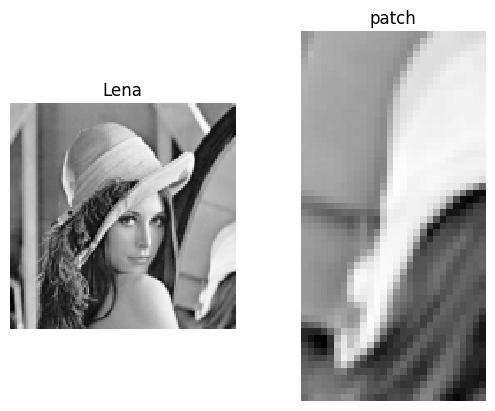

In [6]:
imageplot(clamp(f),'Lena',[1,2,1])
imageplot(clamp(f0),'patch',[1,2,2])

Ajouter un bruit gaussien additif $\epsilon$, tel que l'image bruitée $f=f_0+\epsilon$ où $\epsilon \approx \mathcal{N}(0,\sigma^2\text{Id}_N)$.
$\epsilon$ est un vecteur aléatoire gaussien de dimension $N$ (où $N$ est le nombre de pixels), de   
- moyenne nulle (centre en 0),  
- de matrice de covariance $\mathcal{N}(0,\sigma^2\text{Id}_N)$
Chaque pixel de bruit suit une loi normale $\mathcal{N}(0,\sigma^2)$, les composantes sont indépendantes entre elles.


128


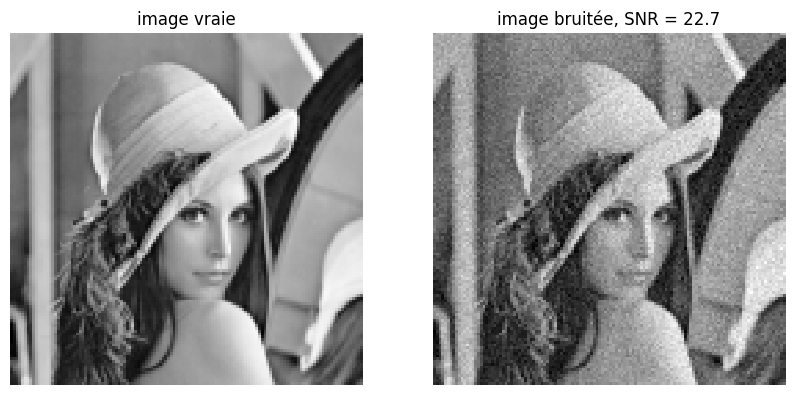

In [24]:
sigma = .04
img = f + np.random.randn(n, n)*sigma
plt.figure(figsize=(10, 10))
print(img.shape[0])
imageplot(clamp(f),'image vraie',[1,2,1])
imageplot(clamp(img),f"image bruitée, SNR = {snr(f,img):.3g}" , [1,2,2])

- On note la demi‑largeur des patchs $w$ et $w_1=2w+1$ la largeur totale. 
- Autrement dit, $w$ est la distance (en pixels) entre le centre du patch et chacun de ses bords.
- La largeur (et la hauteur) totales du patch valent donc $2w+1$

In [29]:
w = 3
w1 = 2*w + 1

Nous construisons les coordonnées des patchs $7×7$ car $w=3$, donc $w_1 = 2 * w + 1 = 7$ autour de chaque pixel, en gérant les bords par réflexion. 
Nous construisons des matrices de tailles $(n,n,w_1,w_1)$ pour indexer les position de X et Y du pixel à extraire. 
- Localisation des pixels.
- Décalage (offsets)
- Localisation des pixels à extraire

In [ ]:
import numpy as np
# Paramètres et grilles de base
[Y, X] = np.meshgrid(np.arange(n), np.arange(n))
# Décalages dans le patch on crée les offsets du patch :
[dY, dX] = np.meshgrid(np.arange(-3,3+1),np.arange(-3,3+1))

In [10]:
dX = dX[None, None, :, :]
dY = dY[None, None, :, :]
X = X[:, :, None, None] + dX
Y = Y[:, :, None, None] + dY

__`Traiter les conditions limites des bors par réflexion`__ 
- pour traiter les bords de l’image (quand un patch ou un filtre « sort » en dehors), 
- on prolonge l’image par réflexion
- les pixels en dehors sont pris comme un miroir de ceux à l’intérieur.

`Gestion des bords par réflexion`
On suppose que les indices valides sont dans [1,n].
- si X < 1 (à gauche), on remplace par 2 - X, ce qui reflète autour de 1.
- si X > n (à droite), on remplace par 2*n - X, réflexion autour de $x$.
- si Y < 1 (à gauche), on remplace par 2 - Y, ce qui reflète autour de 1.
- si Y > n (à droite), on remplace par 2*n - Y, réflexion autour de $y$.

Ce bloc implémente bien une condition de bord réfléchie, les patchs qui dépassent “voient” un miroir de l’image.

In [ ]:
import numpy as np

# X, Y : tableaux (par ex. float ou int)
# n    : entier
# version 0‑based propre (indices dans [0, n-1], patch 7×7,

mask = X < 0
X[mask] = 2 - X[mask]

mask = Y < 0
Y[mask] = 2 - Y[mask]

mask = X > n-1
X[mask] = 2*n - X[mask]

mask = Y > n-1
Y[mask] = 2*n - Y[mask]

# 5) Utilisation : extraction des patchs
# patches[i, j, u, v] = img[ Yc[i,j,u,v], Xc[i,j,u,v] ]
# patches = y[Y, X]   # broadcasting avancé, shape (n, n, 7, 7)

Operateur d'extracteur de patch

In [25]:
import numpy as np
# patch = lambda f: f(X + (Y-1)*n)
# img : image 2D (n, n)
n = img.shape[0]

# vectorisation colonne par colonne
f = img.T.reshape(-1)   # ou img.reshape(-1, order='F')

# X, Y : indices 0-based de taille (n, n, w1, w1)
# ind_lin = X + Y * n
ind = X + Y * n         # même shape que X, Y

def patch(f_vec):
    return f_vec[ind]   # renvoie les patchs

- Définir la matrice du patch $P$ de taille $(n,n,w_1,w_1)$ 
- Chaque $|P(i,j,:,:)|$ représente un patch $(w_1,w_1)$ extrait autour du pixel $(i,j)$ dans l'image.

In [26]:
P = patch(f)

Afficher différents exemples de patchs

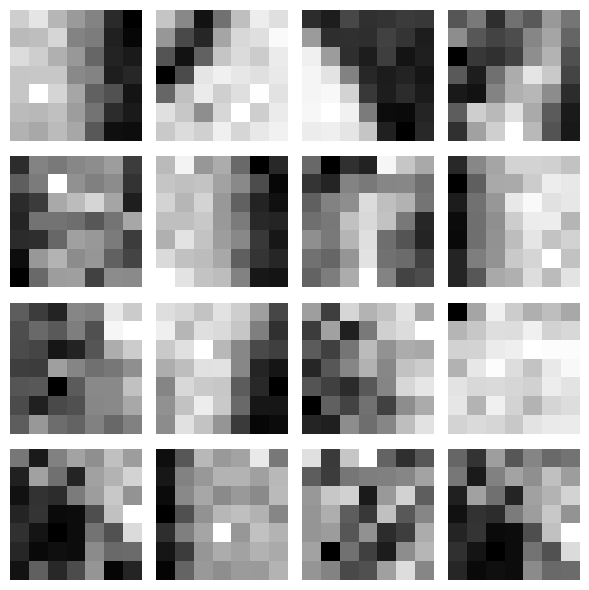

In [47]:
import numpy as np
import matplotlib.pyplot as plt

img = P 
n = P.shape[0]

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i in range(16):
    x = np.random.randint(w, n - w)
    y = np.random.randint(w, n - w)

    patch = img[y-w:y+w+1, x-w:x+w+1]   # shape (2w+1, 2w+1)

    ax = axes[i // 4, i % 4]
    ax.imshow(patch, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
for i in 1: 16:
    x = floor(rand*(n-1) + 1)
    y = floor(rand*(n-1) + 1)
    imageplot(squeeze(P(x, y, : , : )), '', 4, 4, i)

Dimensionality Reduction with PCA
---------------------------------
Since NL-means type algorithms require the computation of many distances
between patches, it is advantagous to reduce the dimensionality of the
patch while keeping as much as possible of information.


Target dimensionality $d$.

In [ ]:
d = 25

A linear dimensionality reduction is obtained by Principal Component
Analysis (PCA) that projects the data on a small number of leading
direction of the coveriance matrix of the patches.


Turn the patch matrix into an |(w1*w1,n*n)| array, so that each |P(:,i)|
is a |w1*w1| vector representing a patch.

In [ ]:
resh = lambda P: reshape(P, [n*n w1*w1])'

operator to remove the mean of the patches to each patch.

In [ ]:
remove_mean = lambda Q: Q - repmat(mean(Q), [w1*w1 1])

Compute the mean and the covariance of the points cloud representing the
patches.

In [ ]:
P1 = remove_mean(resh(P))
C = P1*P1'

Extract the eigenvectors, sorted by decreasing amplitude

In [ ]:
[V, D] = eig(C); D = diag(D)
[D, I] = sort(D, 'descend'); V = V(: , I)

Display the decaying amplitude of the eigenvalues.

In [ ]:
plot(D); axis('tight')

Display the leading eigenvectors - they look like Fourier modes.

In [ ]:
for i in 1: 16:
    imageplot(reshape(V(: , i), [w1 w1]), '', 4, 4, i)

Patch dimensionality reduction operator.

In [ ]:
iresh = lambda Q: reshape(Q', [n n d])
descriptor = lambda f: iresh(V(: , 1: d)' * remove_mean(resh(P)))

Each |H(i,j,:)| is a $d$-dimensional descriptor
of a patch.

In [ ]:
H = descriptor(f)

Non-local Filter
----------------
NL-means applies, to each pixel location, an adaptive averaging kernel
that is computed from patch distances.


We denote $H_{i} \in \RR^d$ the descriptor at pixel $i$.
We define the distance matrix
$$ D_{i,j} = \frac{1}{w_1^2}\norm{H_i-H_j}^2. $$



Operator to compute the distances $(D_{i,j})_j$ between the patch around $i=(i_1,i_2)$
and all the other ones.

In [ ]:
distance = lambda i: sum((H - repmat(H(i(1), i(2), : ), [n n 1])).^2, 3)/ (w1*w1)

The non-local mean filter compute a denoised image $\tilde f$ as
$$ \tilde f_i = \sum_j K_{i,j} f_j $$
where the weights $K$ are computed as
$$ K_{i,j} = \frac{ \tilde K_{i,j} }{ \sum_{j'} \tilde K_{i,j'} }
      \qandq
   \tilde K_{i,j} = e^{-\frac{D_{i,j}}{2\tau^2}} . $$



The width $\tau$ of the Gaussian is very important and should be adapted to match
the noise level.



Compute and normalize the weight.

In [ ]:
normalize = lambda K: K/ sum(K(: ))
kernel = lambda i, tau: normalize(exp(-distance(i)/ (2*tau^2)))

Compute a typical example of kernel for some pixel position $(x,y)$.

In [ ]:
tau = .05
i = [83 72]
D = distance(i)
K = kernel(i, tau)

Display the squared distance and the kernel.

In [ ]:
imageplot(D, 'D', 1, 2, 1)
imageplot(K, 'K', 1, 2, 2)

Localizing the Non-local Means
------------------------------
We set a "locality constant" $q$ that set the maximum distance between
patches to compare. This allows to speed up computation, and makes
NL-means type methods semi-global (to avoid searching in all the image).

In [ ]:
q = 14

Using this locality constant, we compute the distance between patches
only within a window.
Once again, one should be careful about boundary conditions.

In [ ]:
selection = lambda i: {clamp(i(1)-q: i(1) + q, 1, n), clamp(i(2)-q: i(2) + q, 1, n)}

Compute distance and kernel only within the window.

In [ ]:
distance = lambda i, sel: sum((H(sel{1}, sel{2}, : ) - repmat(H(i(1), i(2), : ), ...
        [length(sel{1}) length(sel{2}) 1])).^2, 3)/ (w1*w1)
distance = lambda i: distance(i, selection(i))
kernel = lambda i, tau: normalize(exp(-distance(i)/ (2*tau^2)))

Compute a typical example of kernel for some pixel position $(x,y)$.

In [ ]:
D = distance(i)
K = kernel(i, tau)

Display the squared distance and the kernel.

In [ ]:
imageplot(D, 'D', 1, 2, 1)
imageplot(K, 'K', 1, 2, 2)

The NL-filtered value at pixel $(x,y)$ is obtained by averaging the values
of $f$ with the weight $K$.

In [ ]:
NLval = lambda K, sel: sum(sum(K.*f(sel{1}, sel{2})))
NLval = lambda i, tau: NLval(kernel(i, tau), selection(i))

We apply the filter to each pixel location
to perform the NL-means algorithm.

In [ ]:
[Y, X] = meshgrid(1: n, 1: n)
NLmeans = lambda tau: arrayfun(lambda i1, i2: NLval([i1 i2], tau), X, Y)

Display the result for some value of $\tau$.

In [ ]:
tau = .03

imageplot(NLmeans(tau))

__Exercise 1__

Compute the denoising result for several values of $\tau$ in order to
determine the optimal denoising that minimizes $\norm{\tilde f - f_0}$.

In [ ]:
solutions.exo1()

In [ ]:
## Insert your code here.

Display the best result.

In [ ]:
imageplot(clamp(fNL))

__Exercise 2__

Explore the influence of the $q$ and $w$ parameters.

In [ ]:
solutions.exo2()

In [ ]:
## Insert your code here.

Bibliography
------------
<html><a name="biblio"></a></html>


* [BuaCoMoA05] Buades, B. Coll, J.f Morel, [A review of image denoising algorithms, with a new one][1], SIAM Multiscale Modeling and Simulation, Vol 4 (2), pp: 490-530, 2005.

[1]:http://dx.doi.org/10.1137/040616024